# Notebook 1 — Data Processing

This notebook loads and cleans all raw data sources used in the OFAMS brain
age analysis, and produces the master dataframes passed to subsequent notebooks.

## Contents

**1.1 Setup**
Imports, constants, and helper functions (`add_protocol_info`,
`standardize_sessions`, `remove_outliers`).

**1.2 Load clinical data**
Load and clean EDSS scores, fatigue scores, disease characteristics,
and pre-calculated subject ages.

**1.3 Load brain age predictions**
Load raw model output from pyment, brainageR, and HBA. Add protocol
and scanner metadata, standardize session labels, and compute BAG.

**1.4 Outlier removal**
Identify and remove observations where |BAG z-score| > 3.0.
Flagged subjects are visually inspected in FSLeyes before removal.

**1.5 Build master dataframes**
Merge brain age predictions with clinical variables into one master
dataframe per model (`pyment_master`, `bar_master`, `hba_master`).
These are saved to disk and loaded by all subsequent notebooks.

## 1.1 Setup
Import libraries and set paths

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

In [5]:
print(f"numpy:       {np.__version__}")
#print(f"matplotlib:  {plt.__version__}")
print(f"seaborn:     {sns.__version__}")
#print(f"scipy:       {scipy.__version__}")
print(f"statsmodels: {smf.__version__}")

numpy:       1.26.4
seaborn:     0.13.2


AttributeError: module 'statsmodels.formula.api' has no attribute '__version__'

In [80]:
# Create paths
PATH_PYMENT    = "pyment_predictions_run2.csv"       
PATH_BAR       = "brainageR_predictions_run2.csv"    
PATH_HBA       = "hba_ofams_predictions_run2.csv"        
PATH_AGE       = "Age_calculated.csv"
PATH_DISEASE   = "dato.csv"
PATH_FOLLOWUP  = "follow_up_info.xlsx"
PATH_EDSS      = "edss_long_clean.csv"
PATH_FATIGUE   = "fatigue.csv"                  

# Save cleaned files at the end of notebook:
OUT_PYMENT   = "clean_pyment.csv"
OUT_BAR      = "clean_brainageR.csv"
OUT_HBA      = "clean_hba.csv"
OUT_EDSS     = "clean_edss.csv"
OUT_DISEASE  = "clean_disease.csv"
OUT_FATIGUE  = "clean_fatigue.csv"

### Helper functions

In [82]:
# Protocol map: subjekt-ID // 100 gives protocol-number
# Protocol decides MRI-scanner and fieldstrength
PROTOCOL_MAP = {
    1: ('1.5T', 'Siemens'),  2: ('3T', 'Siemens'),
    3: ('3T', 'Siemens'),    4: ('1.5T', 'Siemens'),
    5: ('3T', 'Siemens'),    6: ('1.5T', 'Siemens'),
    7: ('1.5T', 'Siemens'),  8: ('1.5T', 'Philips'),
    9: ('3T', 'Philips'),   10: ('3T', 'Siemens'),
    11:('1.5T','Philips'),  12: ('1.5T', 'Toshiba'),
    13:('3T', 'Philips'),   14: ('3T', 'Siemens'),
    15:('1.5T','Philips')
}

SESSION_ORDER = [
    'baseline','m1','m2','m3','m4','m5',
    'm6','m7','m8','m9','m12','m18','m24','m120'
]
SESSION_MONTHS = {
    'baseline': 0, 'm1': 1,  'm2': 2,  'm3': 3,
    'm4': 4,  'm5': 5,  'm6': 6,  'm7': 7,
    'm8': 8,  'm9': 9,  'm12': 12, 'm18': 18,
    'm24': 24, 'm120': 120
}

In [83]:
def add_protocol_info(df):
    """Add protocol, field strength, and manufacturer columns based on subject ID."""
    df = df.copy()

    # Derive protocol number from subject ID (integer division by 100)
    df['protocol'] = (df['subject'] // 100).astype(int)

    # Map protocol number to field strength and manufacturer using PROTOCOL_MAP
    df['field_strength'] = df['protocol'].map(
        lambda x: PROTOCOL_MAP.get(x, (None, None))[0])
    df['manufacturer'] = df['protocol'].map(
        lambda x: PROTOCOL_MAP.get(x, (None, None))[1])

    return df


def standardize_sessions(df):
    """Standardize session labels to lowercase strings with no leading/trailing whitespace."""
    df = df.copy()

    # Strip whitespace and convert to lowercase
    df['session'] = df['session'].astype(str).str.strip().str.lower()

    # Normalize alternative baseline labels to a single consistent value
    df['session'] = df['session'].replace({'bl': 'baseline', '0': 'baseline'})

    return df


def remove_outliers(df, bag_col='BAG', z_thresh=3.0):
    """
    Remove observations where the absolute BAG z-score exceeds z_thresh.

    Under a normal distribution, 99.7% of values fall within ±3 SD.
    Observations outside this range are likely preprocessing artefacts.

    Returns
    -------
    clean_df : DataFrame
        Observations within the z-score threshold.
    removed_df : DataFrame
        Observations flagged as outliers.
    """
    mean = df[bag_col].mean()
    std  = df[bag_col].std()

    df = df.copy()

    # Compute z-score for each BAG observation
    df['BAG_z'] = (df[bag_col] - mean) / std

    mask = df['BAG_z'].abs() > z_thresh

    return df[~mask].copy(), df[mask].copy()

## 1.2 Load data

In [85]:
# Load brainage predictions (pyment, brainageR, HBA)
pyment = pd.read_csv(PATH_PYMENT)
hba = pd.read_csv(PATH_HBA)
bar = pd.read_csv(PATH_BAR)

In [86]:
# Load pre-calculated age data (computed in Calculate_Age.ipynb)
age_df = pd.read_csv(PATH_AGE)

# Standardize session labels (e.g. 'bl' → 'baseline')
age_df = standardize_sessions(age_df)

# Ensure subject ID is integer type for consistent merging
age_df['subject'] = age_df['subject'].astype(int)

# Convert age to numeric, setting unparseable values to NaN
age_df['age'] = pd.to_numeric(age_df['age'], errors='coerce')

print("Age_calculated cols:", age_df.columns.tolist())
print(f"Shape: {age_df.shape}")
print(age_df.head(3))

Age_calculated cols: ['subject', 'session', 'age']
Shape: (1230, 3)
   subject   session        age
0      101  baseline  35.000000
1      101        m1  35.082136
2      101        m2  35.169747


In [87]:
# Load EDSS 
edss = pd.read_csv(PATH_EDSS)
edss.columns

Index(['subject', 'session', 'edss_score'], dtype='object')

In [88]:
# Load raw fatigue data from CSV
raw_fatigue = pd.read_csv(PATH_FATIGUE)
print("Fatigue columns:", raw_fatigue.columns.tolist())
print(raw_fatigue.head(3))

# Rename subject identifier column to match naming convention used across datasets
raw_fatigue = raw_fatigue.rename(columns={'eid': 'subject'})

# Column name for fatigue score (defined as variable for easy updating)
FATIGUE_COL = 'fatigue'

# Ensure subject ID is integer type for consistent merging
raw_fatigue['subject'] = raw_fatigue['subject'].astype(int)

# Standardize session labels (e.g. 'bl' → 'baseline')
raw_fatigue = standardize_sessions(raw_fatigue)

# Keep only relevant columns and drop rows with missing fatigue scores
fatigue_clean = raw_fatigue[['subject', 'session', FATIGUE_COL]].dropna()
print(f"Fatigue: {len(fatigue_clean)} obs")
fatigue_clean.head(3)

Fatigue columns: ['Unnamed: 0', 'eid', 'session', 'fatigue']
   Unnamed: 0  eid  session   fatigue
0           1  101        1  6.888889
1           2  101        7  6.777778
2           3  101       13  6.888889
Fatigue: 343 obs


,subject,session,fatigue
0,101,1,6.888889
1,101,7,6.777778
2,101,13,6.888889


In [89]:
fatigue_clean["session"].unique()

array(['1', '7', '13', '25'], dtype=object)

In [90]:
# Fatigue timepoints are recorded as months from study start (1, 7, 13, 25),
# which are offset from the MRI session labels used in other datasets.
# Map to the shared session naming convention used across all dataframes.
SESSION_MONTHS = {
    "1":  "baseline",
    "7":  "m6",
    "13": "m12",
    "25": "m24"
}

fatigue_clean['session'] = fatigue_clean['session'].map(SESSION_MONTHS)

In [91]:
# load disease data
disease = pd.read_csv(PATH_DISEASE)
print("Disease cols:", disease.columns.tolist())

# Rename cols
disease = disease.rename(columns={
    'Patnr':  'subject',   # TODO: tilpass
    'Gender': 'sex',       # TODO: tilpass
})

# Convert sex to category
disease['subject'] = disease['subject'].astype(int)
disease['sex'] = disease['sex'].replace({
    0: 'M', 1: 'F', 0.0: 'M', 1.0: 'F',
    'Male': 'M', 'Female': 'F'
})

DISEASE_COLS = ['subject', 'sex', 'DISEASE_DURATION', 'SYMPTOM_DURATION',
                'AGE_SYMPTOM_ONSET', 'AGE_DIAGNOSIS', 'BL_EDSSscore']
disease_clean = disease[[c for c in DISEASE_COLS if c in disease.columns]].copy()

print(f"Disease: {len(disease_clean)} subjects")


# Merge gender into brain age-dataframes
pyment = pd.merge(pyment, disease_clean[['subject','sex']], on='subject', how='left')
bar    = pd.merge(bar,    disease_clean[['subject','sex']], on='subject', how='left')
hba    = pd.merge(hba,    disease_clean[['subject','sex']], on='subject', how='left')

disease_clean.head(3)

Disease cols: ['Unnamed: 0', 'Patnr', 'Gender', 'SC_weight', 'SC_height', 'BMI', 'Year_of_birth', 'Year_BL', 'Age_Inclusion', 'YEAROFFIRSTSYMPTOM', 'YEAROFDIAGNOSIS', 'YEAROFSCREENING', 'DISEASE_DURATION', 'SYMPTOM_DURATION', 'AGE_SYMPTOM_ONSET', 'AGE_DIAGNOSIS', 'BL_EDSSscore']
Disease: 88 subjects


,subject,sex,DISEASE_DURATION,SYMPTOM_DURATION,AGE_SYMPTOM_ONSET,AGE_DIAGNOSIS,BL_EDSSscore
0,101,F,0,2,32,34,1.5
1,103,M,1,2,22,23,2.5
2,104,F,0,18,29,47,1.5


## 1.3 Clean and standardize prediction data

In [93]:
# Keep only necessary cols
pyment = pyment[["subject","session","predicted_age","sex"]]

bar = bar[["subject","session", "brain.predicted_age","sex"]]
bar = bar.rename(columns={"brain.predicted_age":"predicted_age"})

hba =hba[["subject","session","age", "brainage","corrected_brainage","sex"]] 
hba = hba.rename(columns={"brainage":"predicted_age"}) #predicted_age =  brain age

In [94]:
print(pyment.shape)
pyment.isna().sum()

(1096, 4)


subject           0
session           0
predicted_age    12
sex              14
dtype: int64

In [95]:
print(bar.shape)
bar.isna().sum()

(1144, 4)


subject          24
session          24
predicted_age    60
sex              38
dtype: int64

24 columns were empty in the csv file. 60-24 = 36 missing predictions, and 14 missing sex (same as pyment)

In [97]:
print(hba.shape)
hba.isna().sum()

(350, 6)


subject               0
session               0
age                   1
predicted_age         0
corrected_brainage    1
sex                   0
dtype: int64

In [98]:
# Remove duplicates from hba - keep row with lowest MAE

hba_clean = hba.copy()

# Calculate abs. deviation between pred and chron. age 
hba_clean["abs_deviation"] = (hba_clean["predicted_age"] - hba_clean["age"]).abs()
duplicates = hba_clean[hba_clean.duplicated(subset=["subject", "session"], keep=False)].copy()
hba_clean = hba_clean.sort_values(by="abs_deviation", ascending=True)

# Keeop only one row per subject + session:
# Keep row with lowest deviation (best prediction / smallest MAE)
hba_clean = hba_clean.drop_duplicates(subset=["subject", "session"], keep="first")
hba_clean = hba_clean.sort_values(by=["subject", "session"]).reset_index(drop=True)

# Print control info
print(f"Original number of rows: {len(hba)}")
print(f"Number of duplicate rows: {len(duplicates)}")
print(f"Number of rows after duplicate removal: {len(hba_clean)}")

Original number of rows: 350
Number of duplicate rows: 65
Number of rows after duplicate removal: 317


In [99]:
hba_clean = hba_clean[["subject","session","sex","predicted_age", "corrected_brainage"]]
hba_clean

,subject,session,sex,predicted_age,corrected_brainage
0,101,m120,F,40.387276,40.235204
1,101,m24,F,31.079489,30.077149
2,101,m6,F,24.061096,22.933075
3,103,m120,M,40.342963,39.257513
4,103,m6,M,24.829563,22.768398
...,...,...,...,...,...
312,1504,m24,F,50.746125,50.596724
313,1504,m6,F,62.574562,62.295066
314,1505,baseline,M,25.844646,24.928901
315,1505,m24,M,34.287605,NaN


### Calculate Brain Age Gap

In [101]:
#Merge with age_df
pyment = pd.merge(pyment,age_df, on = ["subject","session"], how = "inner")
bar = pd.merge(bar,age_df, on = ["subject","session"], how = "inner")
hba = pd.merge(hba_clean,age_df, on = ["subject","session"], how = "inner")

In [102]:
# Calculate BAG
# BAG > 0: Brain looks older than expected --> accelerated ageing
# BAG < 0: Brain looks younger than expected
def calculate_BAG (df):
    df["BAG"] = df['predicted_age'] - df['age']

    print(f"  → {len(df)} obs, {df['subject'].nunique()} subj, "
          f"BAG: {df['BAG'].mean():+.1f}±{df['BAG'].std():.1f}")
    return df
pyment = calculate_BAG(pyment)
bar = calculate_BAG(bar)
hba = calculate_BAG(hba)

    

  → 1082 obs, 91 subj, BAG: +4.0±6.5
  → 1106 obs, 91 subj, BAG: +12.4±11.1
  → 317 obs, 87 subj, BAG: -2.3±11.1


### Handle missing data

In [104]:
# Remove missing data
print("pyment", pyment.isna().sum())
print("bar", bar.isna().sum())
print("hba", hba.isna().sum())

pyment subject           0
session           0
predicted_age    12
sex               3
age               8
BAG              20
dtype: int64
bar subject           0
session           0
predicted_age    36
sex               3
age               8
BAG              44
dtype: int64
hba subject               0
session               0
sex                   0
predicted_age         0
corrected_brainage    1
age                   1
BAG                   1
dtype: int64


In [105]:
print("pyment shape before:", pyment.shape)
pyment = pyment.dropna(subset=["BAG"])
print("pyment shape after:", pyment.shape)
print("brainageR shape before:", bar.shape)
bar = bar.dropna(subset=["BAG"])
print("brainageR shape after:", bar.shape)
print("HBA shape before:", hba.shape)
hba = hba.dropna(subset=["BAG"])
print("HBA shape after:", hba.shape)

pyment shape before: (1082, 6)
pyment shape after: (1062, 6)
brainageR shape before: (1106, 6)
brainageR shape after: (1062, 6)
HBA shape before: (317, 7)
HBA shape after: (316, 7)


### Add protocol metadata
Add protocol, fiels strength and manufactur

In [107]:
# Add protocol to subject
pyment = add_protocol_info(pyment)
hba = add_protocol_info(hba)
bar = add_protocol_info(bar)


## 1.4 Oulier removal

In [109]:
# Compute z-scores without removing anything, just to see how many would be flagged
print("OUTLIER INSPECTION (|BAG z-score| > 3.0)")
print("=" * 55)

for name, df in [('Pyment', pyment), ('BrainageR', bar), ('HBA', hba)]:
    mean, std = df['BAG'].mean(), df['BAG'].std()
    df_temp = df.copy()
    df_temp['BAG_z'] = (df_temp['BAG'] - mean) / std
    flagged = df_temp[df_temp['BAG_z'].abs() > 3.0]
    print(f"\n{name}: {len(flagged)} potential outlier(s) out of {len(df)} obs")
    if len(flagged) > 0:
        print(flagged[['subject', 'session', 'BAG', 'BAG_z']].to_string(index=False))

OUTLIER INSPECTION (|BAG z-score| > 3.0)

Pyment: 2 potential outlier(s) out of 1062 obs
 subject session        BAG     BAG_z
     605      m3 -16.971882 -3.236466
     704      m5 -18.146153 -3.417496

BrainageR: 4 potential outlier(s) out of 1062 obs
 subject session      BAG     BAG_z
  1407.0    m120 -23.0466 -3.211418
   208.0    m120 -23.1329 -3.219228
   811.0    m120 -20.9119 -3.018251
   815.0    m120 -21.9202 -3.109491

HBA: 2 potential outlier(s) out of 316 obs
 subject session        BAG     BAG_z
     606      m6  31.784609  3.082054
    1410    m120 -36.481263 -3.095821


### Outlier inspection — visual review of raw MRI scans

Flagged subjects were visually inspected in FSLeyes before removal.

**Pyment** — all flagged subjects show severe skull-stripping failure
(large portions of brain tissue removed during preprocessing).
Removal is justified; these are preprocessing artefacts, not biological signal.

**BrainageR** — all outliers belong to the `m120` timepoint, which was acquired
with the FLASH sequence. This may reflect reduced model accuracy on FLASH data,
as brainageR was primarily trained on MP-RAGE acquisitions.
Removal is conservative but warranted given the systematic pattern.

**HBA** — no visible artefacts in the raw images; deviations may reflect
genuine biological variation. However, observations are retained for now and
flagged for sensitivity analysis.

In [111]:

# Observations with |z| > 3.0 are removed as likely preprocessing artefacts.
# Under a normal distribution this threshold retains 99.7% of valid data.
print("OUTLIER REMOVAL (|BAG z-score| > 3.0)")
print("=" * 55)

pyment, pyment_removed = remove_outliers(pyment)
bar,    bar_removed    = remove_outliers(bar)
# hba,  hba_removed    = remove_outliers(hba)

for name, clean, removed in [
    ('Pyment',    pyment, pyment_removed),
    ('BrainageR', bar,    bar_removed),
    # ('HBA',     hba,    hba_removed),
]:
    print(f"\n{name}: removed {len(removed)} obs → {len(clean)} remain")
    if len(removed) > 0:
        print(removed[['subject', 'session', 'BAG', 'BAG_z']].to_string(index=False))

OUTLIER REMOVAL (|BAG z-score| > 3.0)

Pyment: removed 2 obs → 1060 remain
 subject session        BAG     BAG_z
     605      m3 -16.971882 -3.236466
     704      m5 -18.146153 -3.417496

BrainageR: removed 4 obs → 1058 remain
 subject session      BAG     BAG_z
  1407.0    m120 -23.0466 -3.211418
   208.0    m120 -23.1329 -3.219228
   811.0    m120 -20.9119 -3.018251
   815.0    m120 -21.9202 -3.109491


## 1.5 Build master dataframe
* Merge everything to one df per model

In [113]:
def build_master(brain_df, name):
    """
    Merge brain age predictions with clinical variables into a single master dataframe.

    Joins EDSS, fatigue, and disease characteristics onto the brain age data,
    then sorts observations chronologically per subject.

    Parameters
    ----------
    brain_df : DataFrame
        Brain age predictions for one model (pyment, brainageR, or HBA).
    name : str
        Model name used for printed summary.

    Returns
    -------
    DataFrame
        Master dataframe with brain age and clinical variables aligned by
        subject and session.
    """
    df = brain_df.copy()

    # Merge clinical scores aligned by subject and session
    df = pd.merge(df, edss,          on=['subject', 'session'], how='left')
    df = pd.merge(df, fatigue_clean, on=['subject', 'session'], how='left')

    # Disease characteristics are session-independent (one row per subject)
    df = pd.merge(df, disease_clean, on=['subject', 'sex'], how='left')

    # Sort observations chronologically using the predefined session order
    sort_map = {s: i for i, s in enumerate(SESSION_ORDER)}
    df['_order'] = df['session'].map(sort_map)
    df = df.sort_values(['subject', '_order']).drop(columns={'_order', 'BL_EDSSscore'})

    print(f"{name}: {len(df)} obs, {df['subject'].nunique()} subj, "
          f"columns: {df.columns.tolist()}")

    return df


# Build master dataframe for each model
pyment_master = build_master(pyment, 'Pyment')
bar_master    = build_master(bar,    'BrainageR')
hba_master    = build_master(hba,    'HBA')

Pyment: 1060 obs, 91 subj, columns: ['subject', 'session', 'predicted_age', 'sex', 'age', 'BAG', 'protocol', 'field_strength', 'manufacturer', 'BAG_z', 'edss_score', 'fatigue', 'DISEASE_DURATION', 'SYMPTOM_DURATION', 'AGE_SYMPTOM_ONSET', 'AGE_DIAGNOSIS']
BrainageR: 1058 obs, 91 subj, columns: ['subject', 'session', 'predicted_age', 'sex', 'age', 'BAG', 'protocol', 'field_strength', 'manufacturer', 'BAG_z', 'edss_score', 'fatigue', 'DISEASE_DURATION', 'SYMPTOM_DURATION', 'AGE_SYMPTOM_ONSET', 'AGE_DIAGNOSIS']
HBA: 316 obs, 87 subj, columns: ['subject', 'session', 'sex', 'predicted_age', 'corrected_brainage', 'age', 'BAG', 'protocol', 'field_strength', 'manufacturer', 'edss_score', 'fatigue', 'DISEASE_DURATION', 'SYMPTOM_DURATION', 'AGE_SYMPTOM_ONSET', 'AGE_DIAGNOSIS']


In [114]:
pyment_master.columns

Index(['subject', 'session', 'predicted_age', 'sex', 'age', 'BAG', 'protocol',
       'field_strength', 'manufacturer', 'BAG_z', 'edss_score', 'fatigue',
       'DISEASE_DURATION', 'SYMPTOM_DURATION', 'AGE_SYMPTOM_ONSET',
       'AGE_DIAGNOSIS'],
      dtype='object')

### Sample characteristics 

In [116]:
# Model-to-dataframe mapping for iteration
models = {
    "pyment":    pyment_master,
    "brainageR": bar_master,
    "HBA":       hba_master
}

# All expected timepoints in chronological order
timepoints = [
    "baseline", "m1", "m2", "m3", "m4", "m5",
    "m6", "m7", "m8", "m9", "m12", "m18", "m24", "m120"
]

# ── Sample characteristics table ──────────────────────────────────────────────
# Summarize subject count, scan count, and baseline demographics per model
summary = []
for name, df in models.items():
    bl = df[df["session"] == "baseline"]  # Baseline subset for demographic stats
    summary.append({
        "Model":               name,
        "Subjects":            df["subject"].nunique(),
        "Baseline scans":      len(bl),
        "Total predictions":   len(df),
        "Mean age (BL)":       f"{bl['age'].mean():.2f} ± {bl['age'].std():.2f}",
        "Mean DD (BL)":        f"{bl['DISEASE_DURATION'].mean():.2f} ± {bl['DISEASE_DURATION'].std():.2f}"
    })

sample_char = pd.DataFrame(summary)
print(sample_char)

# ── Longitudinal scan availability ────────────────────────────────────────────
# Count number of predictions per timepoint for each model
availability = []
for name, df in models.items():
    row = {"Model": name}
    for tp in timepoints:
        row[tp] = (df["session"] == tp).sum()
    availability.append(row)

availability_df = pd.DataFrame(availability)
print(availability_df)

       Model  Subjects  Baseline scans  Total predictions Mean age (BL)  \
0     pyment        91              83               1060  38.70 ± 8.47   
1  brainageR        91              83               1058  38.70 ± 8.47   
2        HBA        87              69                316  38.94 ± 8.69   

  Mean DD (BL)  
0  1.88 ± 3.16  
1  1.88 ± 3.16  
2  1.68 ± 2.81  
       Model  baseline  m1  m2  m3  m4  m5  m6  m7  m8  m9  m12  m18  m24  \
0     pyment        83  84  85  80  77  79  86  85  82  82   84    0   78   
1  brainageR        83  84  85  81  77  80  86  85  82  82   84    0   78   
2        HBA        69   8   5   3   1  11  70   5   3   3    3    0   66   

   m120  
0    75  
1    71  
2    69  


In [117]:
def find_subjects_without_baseline(df, model_name="Model", baseline_label="baseline"):
    """
    Finds subjects without a baseline scan and lists available sessions.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing at least 'subject' and 'session'
    model_name : str
        Name of the model/dataframe
    baseline_label : str
        Label used for baseline session
        
    Returns
    -------
    pandas.DataFrame
        Subjects without baseline and their available sessions
    """
    
    # All subjects
    all_subjects = set(df["subject"].unique())

    # Subjects with baseline
    baseline_subjects = set(
        df[df["session"] == baseline_label]["subject"].unique()
    )

    # Subjects missing baseline
    missing_baseline = all_subjects - baseline_subjects

    # Extract rows for these subjects
    missing_df = df[df["subject"].isin(missing_baseline)]

    # Group sessions per subject
    summary = (
        missing_df.groupby("subject")["session"]
        .apply(list)
        .reset_index()
        .rename(columns={"session": "available_sessions"})
    )

    print(f"\n--- {model_name} ---")
    print(f"Subjects without baseline: {len(summary)}")

    return summary


# Run for all models
pyment_missing = find_subjects_without_baseline(
    pyment_master,
    model_name="pyment"
)

bar_missing = find_subjects_without_baseline(
    bar_master,
    model_name="brainageR"
)

hba_missing = find_subjects_without_baseline(
    hba_master,
    model_name="HBA"
)

# Display results
print(pyment_missing)
print(bar_missing)
print(hba_missing)


--- pyment ---
Subjects without baseline: 8

--- brainageR ---
Subjects without baseline: 8

--- HBA ---
Subjects without baseline: 18
   subject                                 available_sessions
0      403                                             [m120]
1      604                                             [m120]
2     1103   [m1, m2, m3, m4, m6, m7, m8, m9, m12, m24, m120]
3     1106                                             [m120]
4     1407  [m1, m2, m3, m4, m5, m6, m7, m8, m9, m12, m24,...
5     1408                                             [m120]
6     1501  [m1, m2, m3, m4, m5, m6, m7, m8, m9, m12, m24,...
7     1504     [m1, m2, m3, m4, m5, m6, m7, m8, m9, m12, m24]
   subject                                 available_sessions
0    403.0                                             [m120]
1    604.0                                             [m120]
2   1103.0   [m1, m2, m3, m4, m6, m7, m8, m9, m12, m24, m120]
3   1106.0                                             [m1

### Quality Control Plots

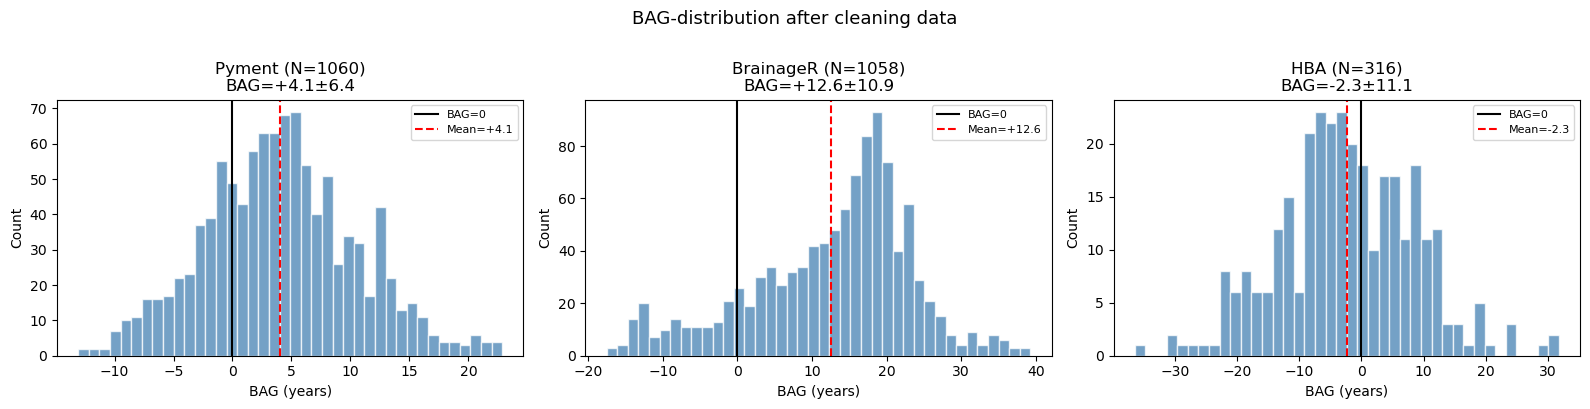

In [119]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, (name, df) in enumerate([
    ('Pyment', pyment_master),
    ('BrainageR', bar_master),
    ('HBA', hba_master)
]):
    axes[i].hist(df['BAG'].dropna(), bins=40,
                 color='steelblue', alpha=0.75, edgecolor='white')
    axes[i].axvline(0, color='black', lw=1.5, label='BAG=0')
    axes[i].axvline(df['BAG'].mean(), color='red', lw=1.5,
                    linestyle='--', label=f"Mean={df['BAG'].mean():+.1f}")
    axes[i].set_title(f'{name} (N={len(df)})\nBAG={df["BAG"].mean():+.1f}±{df["BAG"].std():.1f}')
    axes[i].set_xlabel('BAG (years)')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

plt.suptitle('BAG-distribution after cleaning data', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('QC_BAG_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Save files

In [121]:
pyment_master.to_csv(OUT_PYMENT,  index=False, encoding='utf-8-sig')
bar_master.to_csv(   OUT_BAR,     index=False, encoding='utf-8-sig')
hba_master.to_csv(   OUT_HBA,     index=False, encoding='utf-8-sig')
edss.to_csv(   OUT_EDSS,    index=False, encoding='utf-8-sig')
disease_clean.to_csv(OUT_DISEASE, index=False, encoding='utf-8-sig')
fatigue_clean.to_csv(OUT_FATIGUE, index=False, encoding='utf-8-sig')

print("\nSaved:")
for f in [OUT_PYMENT, OUT_BAR, OUT_HBA, OUT_EDSS, OUT_DISEASE, OUT_FATIGUE]:
    print(f"  {f}")



Saved:
  clean_pyment.csv
  clean_brainageR.csv
  clean_hba.csv
  clean_edss.csv
  clean_disease.csv
  clean_fatigue.csv
